<a href="https://www.kaggle.com/code/lalit7881/e-commerce-ram-trends-2026-eda?scriptVersionId=314943340" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kanchana1990/e-commerce-ram-pricing-intelligence-2026/ram_pricing_intelligence_2026.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/kanchana1990/e-commerce-ram-pricing-intelligence-2026/ram_pricing_intelligence_2026.csv")

In [3]:
df.head()

,ram_generation,brand,seller_id,condition,title,capacity_gb,bus_speed_mhz,unit_type,price,wasPrice,available,sold,itemLocation,lastUpdated,mpn,type,is_bulk_server
0,DDR4,SK hynix,Seller_0001,Used,SK Hynix 64GB 4DRx4 PC4-2400T DDR4 ECC Server ...,64.0,2400.0,Single,229.00,NaN,6.0,2.0,"Lakeville, Minnesota, United States",2026-04-24 21:22:14,HMAA8GL7MMR4NUH,DDR4 SDRAM,1
1,DDR4,A-Tech,Seller_0002,New,A-Tech 32GB 2x 16GB PC4-21300 Laptop SODIMM 26...,32.0,2666.0,Dual Kit,231.98,NaN,10.0,1728.0,"Columbus, Ohio, United States",2026-04-20 10:40:28,AT16G2D4S2666ND8N12V,DDR4 SDRAM,0
2,DDR4,Crucial,Seller_0003,Used,16GB Crucial Micron DDR4-2133 PC4-17000 RDIMM ...,16.0,2133.0,Single,57.99,NaN,8.0,28.0,"Las Vegas, Nevada, United States",2026-04-24 20:40:30,"CT16G4RFD4213, CT16G4RFD4213.36FA2, CT16G4RFD4...",DDR4 SDRAM,1
3,DDR4,SK hynix,Seller_0004,Used,SK HYNIX 32GB HMA84GR7MFR4N-UH DDR4-2400 2Rx4 ...,32.0,2400.0,Single,189.99,NaN,10.0,3.0,"Wauconda, Illinois, United States",2026-04-18 08:03:11,HMA84GR7MFR4NUH,ECC RAM,0
4,DDR4,RAM,Seller_0005,Used,Mixed Brand 8GB DDR4 Desktop RAM PC4 UDIMM - C...,8.0,NaN,Single,23.49,NaN,6.0,51.0,"Auburn Hills, Michigan, United States",2026-04-23 08:31:55,NaN,DDR4 SDRAM,0


In [4]:
df.tail()

,ram_generation,brand,seller_id,condition,title,capacity_gb,bus_speed_mhz,unit_type,price,wasPrice,available,sold,itemLocation,lastUpdated,mpn,type,is_bulk_server
2894,DDR5,Corsair,Seller_0537,New,Corsair VENGEANCE RGB 32GB (2x16GB) DDR5-6000 ...,32.0,6000.0,Dual Kit,349.99,NaN,NaN,NaN,"Kansas City, Missouri, United States",NaN,"CMH32GX5M2M6000Z36, AAQIT5024032SEU",DDR5 SDRAM,0
2895,DDR5,A-Tech,Seller_0002,New,16GB 2x8GB PC5-38400S HP Victus 16-d1020ns 16-...,16.0,NaN,Dual Kit,249.98,NaN,10.0,NaN,"Columbus, Ohio, United States",2026-04-24 13:23:25,EB63-A492,DDR5 SDRAM,0
2896,DDR5,A-Tech,Seller_0002,New,16GB DDR5-4800 Lenovo ThinkPad P16 Gen 1 P15v ...,16.0,4800.0,Single,237.49,NaN,10.0,NaN,"Columbus, Ohio, United States",NaN,EB63-A665,DDR5 SDRAM,0
2897,DDR5,Patriot Memory,Seller_0310,New,Patriot Viper Venom RGB 32GB (2x16GB) DDR5 560...,32.0,5600.0,Dual Kit,419.99,NaN,10.0,1.0,"Fremont, California, United States",2026-04-22 17:54:05,"PVVR532G560C36K, PVVR532G600C36K, PVVR532G600C...",DDR5 288-Pin PC UDIMM,0
2898,DDR5,Samsung,Seller_1311,Used,Samsung 16gb (2x8GB) DDR5 SODIMM Laptop Ram,16.0,NaN,Dual Kit,150.00,NaN,NaN,NaN,"Masontown, Pennsylvania, United States",NaN,NaN,DDR5 DRAM,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2899 entries, 0 to 2898
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ram_generation  2899 non-null   object 
 1   brand           2895 non-null   object 
 2   seller_id       2899 non-null   object 
 3   condition       2899 non-null   object 
 4   title           2899 non-null   object 
 5   capacity_gb     2863 non-null   float64
 6   bus_speed_mhz   2272 non-null   float64
 7   unit_type       2899 non-null   object 
 8   price           2899 non-null   float64
 9   wasPrice        123 non-null    float64
 10  available       1770 non-null   float64
 11  sold            920 non-null    float64
 12  itemLocation    2899 non-null   object 
 13  lastUpdated     2110 non-null   object 
 14  mpn             1818 non-null   object 
 15  type            2792 non-null   object 
 16  is_bulk_server  2899 non-null   int64  
dtypes: float64(6), int64(1), object(1

In [6]:
df.describe()

,capacity_gb,bus_speed_mhz,price,wasPrice,available,sold,is_bulk_server
count,2863.000000,2272.000000,2899.00000,123.000000,1770.000000,920.000000,2899.000000
mean,24.810339,4470.590229,267.59890,477.911138,9.815819,39.628261,0.081062
std,37.168248,1581.916062,468.78492,634.528370,25.093876,230.684629,0.272978
min,4.000000,1600.000000,7.00000,18.840000,2.000000,1.000000,0.000000
25%,8.000000,2666.000000,89.99000,196.810000,4.000000,1.000000,0.000000
50%,16.000000,4800.000000,160.00000,349.990000,10.000000,4.000000,0.000000
75%,32.000000,6000.000000,325.00000,574.990000,10.000000,15.000000,0.000000
max,1024.000000,9000.000000,12345.67000,4119.490000,500.000000,4766.000000,1.000000


In [7]:
df.isnull().sum()

ram_generation       0
brand                4
seller_id            0
condition            0
title                0
capacity_gb         36
bus_speed_mhz      627
unit_type            0
price                0
wasPrice          2776
available         1129
sold              1979
itemLocation         0
lastUpdated        789
mpn               1081
type               107
is_bulk_server       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(2)

In [9]:
df.dtypes

ram_generation     object
brand              object
seller_id          object
condition          object
title              object
capacity_gb       float64
bus_speed_mhz     float64
unit_type          object
price             float64
wasPrice          float64
available         float64
sold              float64
itemLocation       object
lastUpdated        object
mpn                object
type               object
is_bulk_server      int64
dtype: object

In [10]:
df.shape

(2899, 17)

In [11]:
df.columns

Index(['ram_generation', 'brand', 'seller_id', 'condition', 'title',
       'capacity_gb', 'bus_speed_mhz', 'unit_type', 'price', 'wasPrice',
       'available', 'sold', 'itemLocation', 'lastUpdated', 'mpn', 'type',
       'is_bulk_server'],
      dtype='object')

In [12]:
df.nunique()

ram_generation       3
brand              149
seller_id         1276
condition            6
title             2821
capacity_gb         21
bus_speed_mhz       31
unit_type            3
price              931
wasPrice           102
available           46
sold               123
itemLocation       855
lastUpdated       1639
mpn               1320
type               139
is_bulk_server       2
dtype: int64

In [13]:
# Basic cleaning
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['wasPrice'] = pd.to_numeric(df['wasPrice'], errors='coerce')
df['capacity_gb'] = pd.to_numeric(df['capacity_gb'], errors='coerce')
df['bus_speed_mhz'] = pd.to_numeric(df['bus_speed_mhz'], errors='coerce')

# Drop missing critical values
df = df.dropna(subset=['price', 'brand'])

## EDA

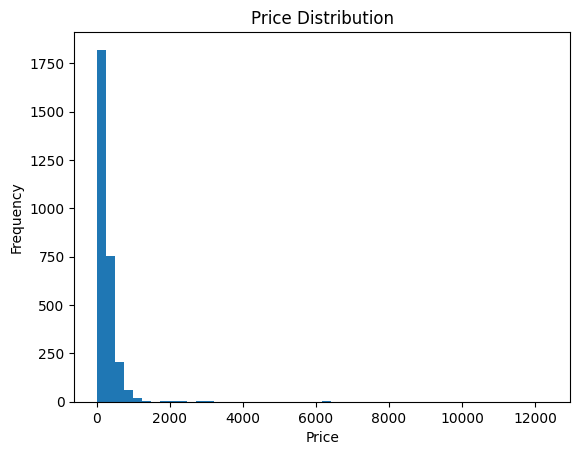

In [14]:
plt.figure()
plt.hist(df['price'], bins=50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

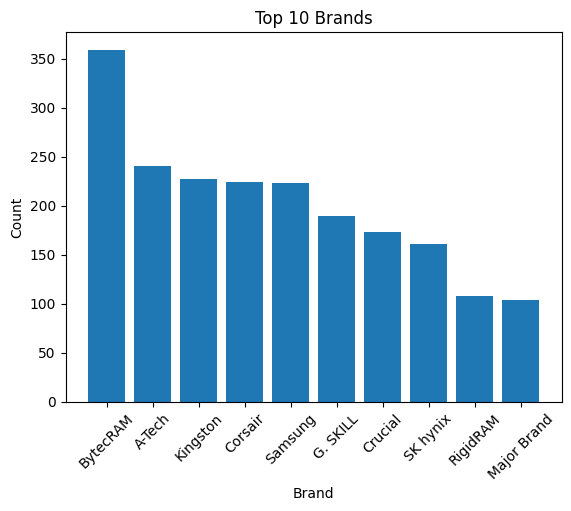

In [15]:
top_brands = df['brand'].value_counts().head(10)

plt.figure()
plt.bar(top_brands.index, top_brands.values)
plt.title("Top 10 Brands")
plt.xticks(rotation=45)
plt.xlabel("Brand")
plt.ylabel("Count")
plt.show()

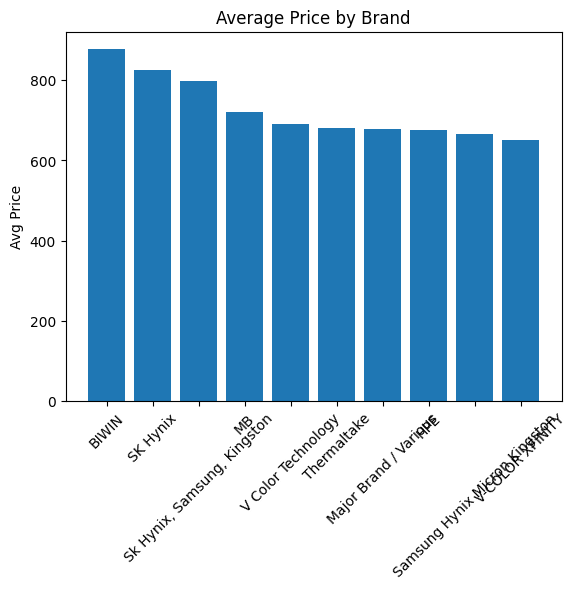

In [16]:
avg_price_brand = df.groupby('brand')['price'].mean().sort_values(ascending=False).head(10)

plt.figure()
plt.bar(avg_price_brand.index, avg_price_brand.values)
plt.title("Average Price by Brand")
plt.xticks(rotation=45)
plt.ylabel("Avg Price")
plt.show()

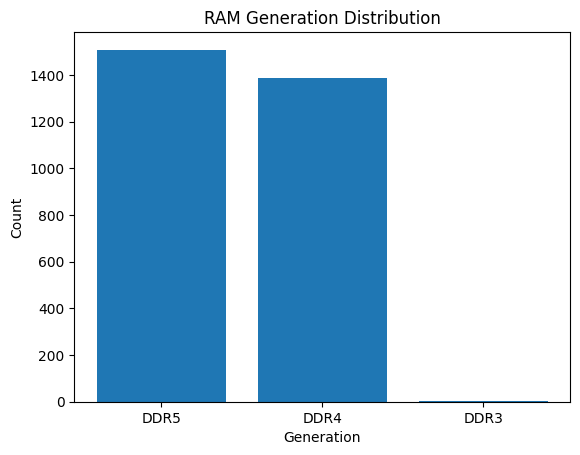

In [17]:
ram_counts = df['ram_generation'].value_counts()

plt.figure()
plt.bar(ram_counts.index.astype(str), ram_counts.values)
plt.title("RAM Generation Distribution")
plt.xlabel("Generation")
plt.ylabel("Count")
plt.show()

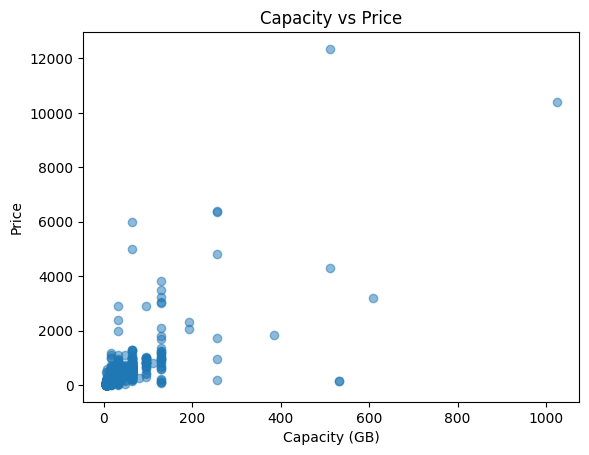

In [18]:
plt.figure()
plt.scatter(df['capacity_gb'], df['price'], alpha=0.5)
plt.title("Capacity vs Price")
plt.xlabel("Capacity (GB)")
plt.ylabel("Price")
plt.show()

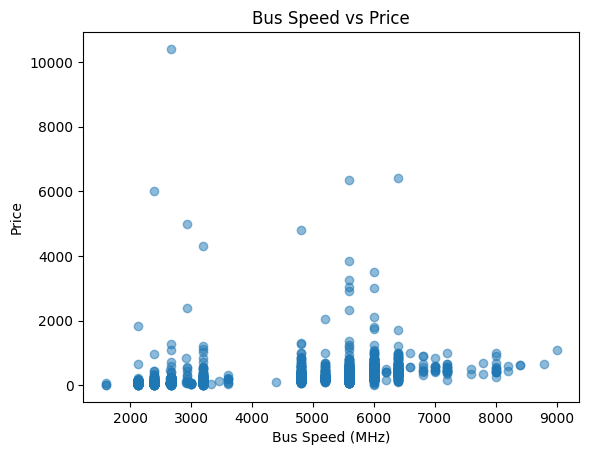

In [19]:
plt.figure()
plt.scatter(df['bus_speed_mhz'], df['price'], alpha=0.5)
plt.title("Bus Speed vs Price")
plt.xlabel("Bus Speed (MHz)")
plt.ylabel("Price")
plt.show()

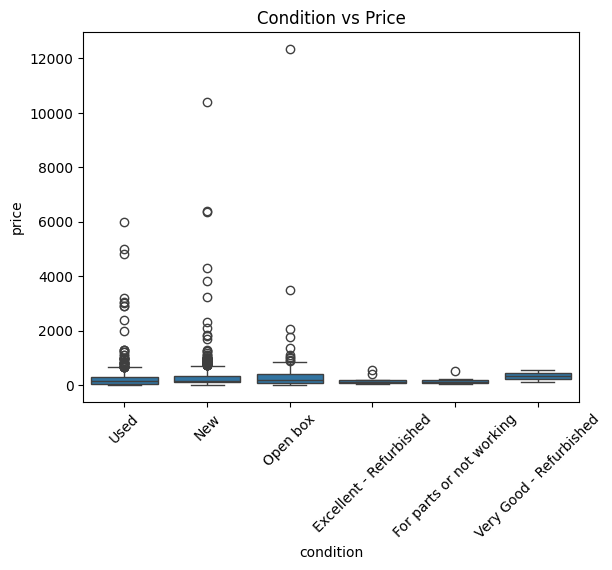

In [20]:
plt.figure()
sns.boxplot(x='condition', y='price', data=df)
plt.title("Condition vs Price")
plt.xticks(rotation=45)
plt.show()

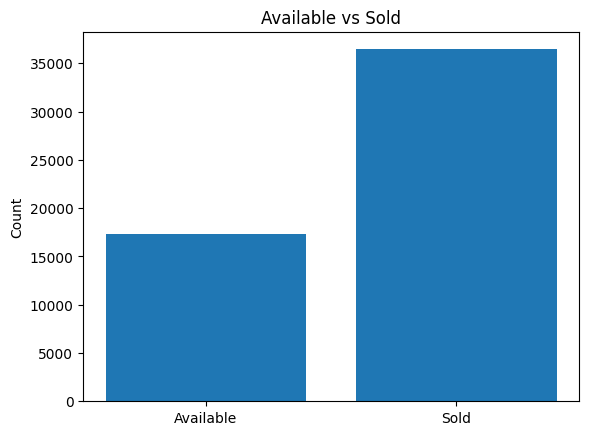

In [21]:
availability = df[['available', 'sold']].sum()

plt.figure()
plt.bar(['Available', 'Sold'], availability.values)
plt.title("Available vs Sold")
plt.ylabel("Count")
plt.show()

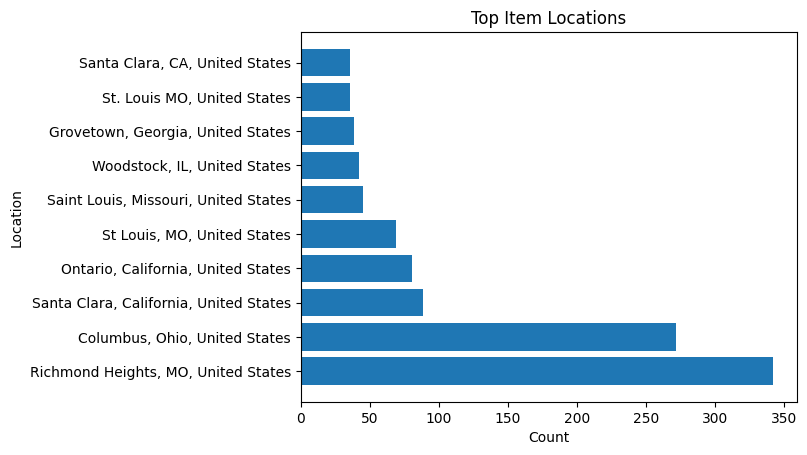

In [22]:
top_locations = df['itemLocation'].value_counts().head(10)

plt.figure()
plt.barh(top_locations.index, top_locations.values)
plt.title("Top Item Locations")
plt.xlabel("Count")
plt.ylabel("Location")
plt.show()

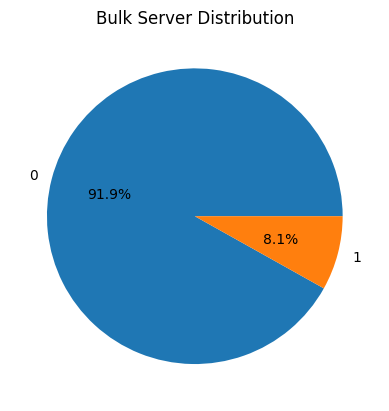

In [23]:
bulk_counts = df['is_bulk_server'].value_counts()

plt.figure()
plt.pie(bulk_counts.values, labels=bulk_counts.index, autopct='%1.1f%%')
plt.title("Bulk Server Distribution")
plt.show()

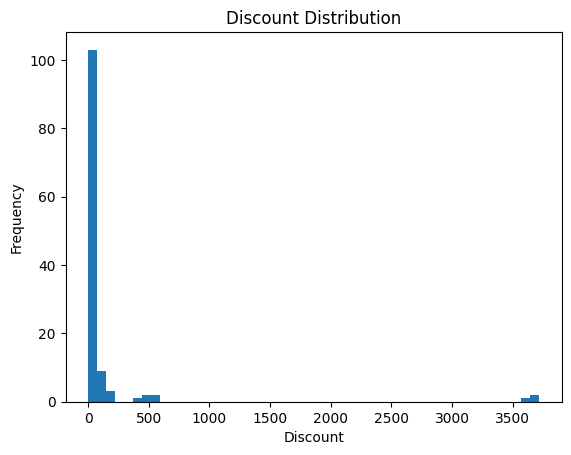

In [24]:
df['discount'] = df['wasPrice'] - df['price']

plt.figure()
plt.hist(df['discount'].dropna(), bins=50)
plt.title("Discount Distribution")
plt.xlabel("Discount")
plt.ylabel("Frequency")
plt.show()

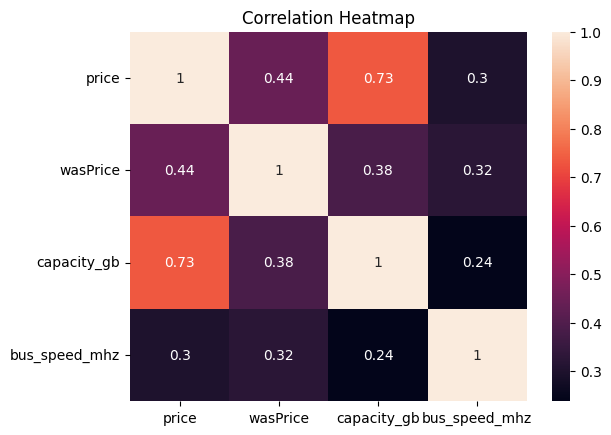

In [25]:
numeric_cols = ['price', 'wasPrice', 'capacity_gb', 'bus_speed_mhz']

corr = df[numeric_cols].corr()

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

## Feature engineering


Target Distribution:
 sold
0    491
1    427
Name: count, dtype: int64

Logistic Regression
Accuracy: 0.6685
AUC Score: 0.7299
              precision    recall  f1-score   support

           0       0.68      0.71      0.70        98
           1       0.65      0.62      0.63        86

    accuracy                           0.67       184
   macro avg       0.67      0.67      0.67       184
weighted avg       0.67      0.67      0.67       184


Random Forest
Accuracy: 0.6848
AUC Score: 0.7368
              precision    recall  f1-score   support

           0       0.69      0.76      0.72        98
           1       0.68      0.60      0.64        86

    accuracy                           0.68       184
   macro avg       0.68      0.68      0.68       184
weighted avg       0.68      0.68      0.68       184



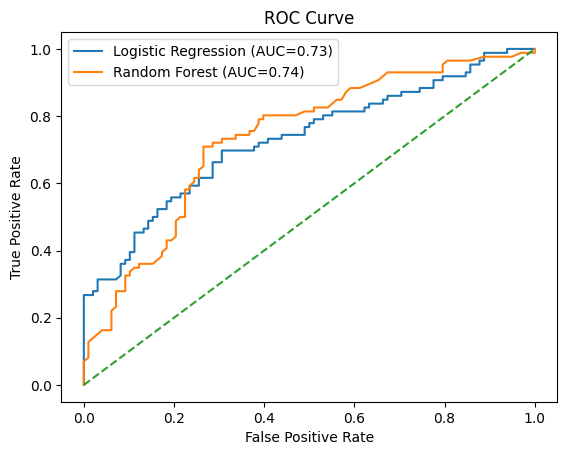

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve

# =========================================
# 3. CLEAN NUMERIC COLUMNS
# =========================================
num_cols = ['price', 'wasPrice', 'capacity_gb', 'bus_speed_mhz']

for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# =========================================
# 4. CREATE ROBUST TARGET (NO FAILURE CASE)
# =========================================
df = df.dropna(subset=['sold'])

# If all values same → fallback to median split
if df['sold'].nunique() == 1:
    raise ValueError("❌ Dataset has only one value in 'sold'. Cannot build model.")

# Create balanced binary target
threshold = df['sold'].median()
y = (df['sold'] > threshold).astype(int)

# If still only one class → force percentile split
if y.nunique() < 2:
    threshold = df['sold'].quantile(0.5)
    y = (df['sold'] > threshold).astype(int)

# FINAL safety check
if y.nunique() < 2:
    raise ValueError("❌ Target still has one class. Need better data.")

print("\nTarget Distribution:\n", y.value_counts())

# =========================================
# 5. FEATURES
# =========================================
drop_cols = ['sold', 'title', 'lastUpdated', 'mpn']
X = df.drop(columns=drop_cols, errors='ignore')

# =========================================
# 6. TRAIN TEST SPLIT (SAFE)
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================================
# 7. PREPROCESSING PIPELINE
# =========================================
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, categorical_cols)
])

# =========================================
# 8. MODELS
# =========================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
}

# =========================================
# 9. TRAIN + EVALUATE
# =========================================
plt.figure()

for name, model in models.items():
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_prob)
    
    print("\n" + "="*40)
    print(name)
    print(f"Accuracy: {acc:.4f}")
    print(f"AUC Score: {auc_score:.4f}")
    print(classification_report(y_test, y_pred))
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.2f})")

# =========================================
# 10. ROC PLOT
# =========================================
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Thank you...pls upvote!!!!!!!!!